**EMPLOYEE PERFORMANCE ANALYSIS**


Project Summary
This project analyzed employee performance data at INX Future Inc to identify key drivers of employee performance and build a predictive model for performance classification.

Using exploratory data analysis, feature importance evaluation, and multi-class model comparison, the most influential factors affecting employee performance were identified.
A Random Forest model was selected as the final predictive model due to its superior and stable performance.

The insights and model developed in this project can assist management in improving employee performance while maintaining employee morale and organizational reputation.

In [2]:
# Install required packages
!pip install -q pandas openpyxl xlrd

# Imports
import pandas as pd
import numpy as np

from google.colab import files
from google.colab import drive

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [8]:
df = pd.read_excel("/INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8 (1).xls")
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3



**Business Problem Understanding**


INX Future Inc is facing a decline in employee performance, which has negatively impacted service delivery and client satisfaction.
The top management aims to identify the underlying factors affecting employee performance without directly penalizing employees, in order to preserve morale and employer brand.

This project focuses on analyzing employee data to:

Understand department-wise performance trends
Identify key factors influencing employee performance
Build a predictive model to classify employee performance levels
Provide actionable recommendations to improve overall performance


**Data Understanding**


The dataset contains employee-level information including demographic attributes, job-related factors, satisfaction scores, and performance ratings.
Initial exploration was performed to understand the structure, data types, and target variable distribution.

**Basic Checks**



In [9]:

# Shape of dataset
df.shape


(1200, 28)

In [10]:
# Dataset structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [11]:

# Statistical summary
df.describe()


,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


**Dataset Overview**
The INX Future Inc employee performance dataset contains structured employee-level data collected across various departments.
It includes demographic information, job-related attributes, satisfaction metrics, and performance ratings.

**Key Characteristics of the Dataset:**


Each row represents an individual employee
Columns capture both numerical and categorical attributes
The dataset is primarily focused on HR and performance evaluation factors
The target variable is PerformanceRating, which categorizes employee performance into three levels
This dataset is suitable for exploratory data analysis and supervised machine learning techniques to derive insights and build predictive models.

**Target Variable Analysis**


The target variable for this project is PerformanceRating, which represents the performance level of employees within INX Future Inc.

The performance ratings are categorized as:

2 → Low Performance
3 → Average Performance
4 → High Performance
Since the target variable consists of three discrete categories, the problem is formulated as a multi-class classification task.

In [12]:
df['PerformanceRating'].value_counts()


,count
PerformanceRating,
3,874
2,194
4,132


In [13]:
df['PerformanceRating'].value_counts(normalize=True)

,proportion
PerformanceRating,
3,0.728333
2,0.161667
4,0.110000


**Target Variable Distribution Interpretation**


The distribution of the PerformanceRating variable shows an imbalance across the three performance categories:

Majority of employees fall under Average Performance (Rating = 3), accounting for approximately 72.8% of the data.
Low Performance (Rating = 2) employees constitute around 16.2% of the dataset.
High Performance (Rating = 4) employees form the smallest group, comprising about 11.0%.
This indicates a noticeable class imbalance, with the majority of employees clustered in the average performance category.

Due to the presence of class imbalance, evaluation metrics beyond simple accuracy will be considered during model evaluation to ensure fair performance across all categories.

  Missing Value Analysis

In [14]:
df.isnull().sum()

,0
EmpNumber,0
Age,0
Gender,0
EducationBackground,0
MaritalStatus,0
EmpDepartment,0
EmpJobRole,0
BusinessTravelFrequency,0
DistanceFromHome,0
EmpEducationLevel,0


**Missing Value Analysis Results**
The missing value analysis indicates that there are no missing values across all features in the dataset.

This confirms that the dataset is complete and does not require any imputation or data removal.
As a result, the original data integrity is preserved, and the dataset is directly suitable for exploratory data analysis and model building.

**Duplicate Record Analysis**

In [15]:

# Check for duplicate rows
df.duplicated().sum()


np.int64(0)

In [16]:
# View duplicate records if any
df[df.duplicated()]


,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating


**Duplicate Record Analysis Results**
The duplicate record check indicates that there are no duplicate entries in the dataset.

This confirms that each row represents a unique employee record, and no duplicate handling or data removal is required.

**Feature Categorization**


To perform effective preprocessing and exploratory data analysis, the features were categorized into numerical and categorical variables based on their data types.

In [17]:
# Identify categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(exclude=['object']).columns.tolist()

categorical_features, numerical_features

(['EmpNumber',
  'Gender',
  'EducationBackground',
  'MaritalStatus',
  'EmpDepartment',
  'EmpJobRole',
  'BusinessTravelFrequency',
  'OverTime',
  'Attrition'],
 ['Age',
  'DistanceFromHome',
  'EmpEducationLevel',
  'EmpEnvironmentSatisfaction',
  'EmpHourlyRate',
  'EmpJobInvolvement',
  'EmpJobLevel',
  'EmpJobSatisfaction',
  'NumCompaniesWorked',
  'EmpLastSalaryHikePercent',
  'EmpRelationshipSatisfaction',
  'TotalWorkExperienceInYears',
  'TrainingTimesLastYear',
  'EmpWorkLifeBalance',
  'ExperienceYearsAtThisCompany',
  'ExperienceYearsInCurrentRole',
  'YearsSinceLastPromotion',
  'YearsWithCurrManager',
  'PerformanceRating'])

**Feature Categorization Results**


Based on data type inspection, the features were categorized as follows:

**Categorical Features:** Gender, EducationBackground, MaritalStatus, EmpDepartment, EmpJobRole, BusinessTravelFrequency, OverTime, Attrition
Numerical Features: Age, DistanceFromHome, education level, satisfaction scores, experience-related attributes, and performance-related metrics
The column EmpNumber was identified as a unique employee identifier and does not contribute to predictive modeling.
Therefore, it will be excluded from further analysis to avoid introducing noise into the model.

In [18]:
df.drop(columns=['EmpNumber'], inplace=True)

**Exploratory Data Analysis (EDA)**


EDA was performed to uncover patterns, relationships, and trends within the employee data that influence performance ratings.
The analysis focuses on department-wise performance, satisfaction metrics, and other key employee attributes.

In [19]:
# Department-wise average performance rating
dept_perf = (
    df.groupby('EmpDepartment')['PerformanceRating']
      .mean()
      .sort_values(ascending=False)
)

dept_perf

,PerformanceRating
EmpDepartment,
Development,3.085873
Data Science,3.050000
Human Resources,2.925926
Research & Development,2.921283
Sales,2.860590
Finance,2.775510


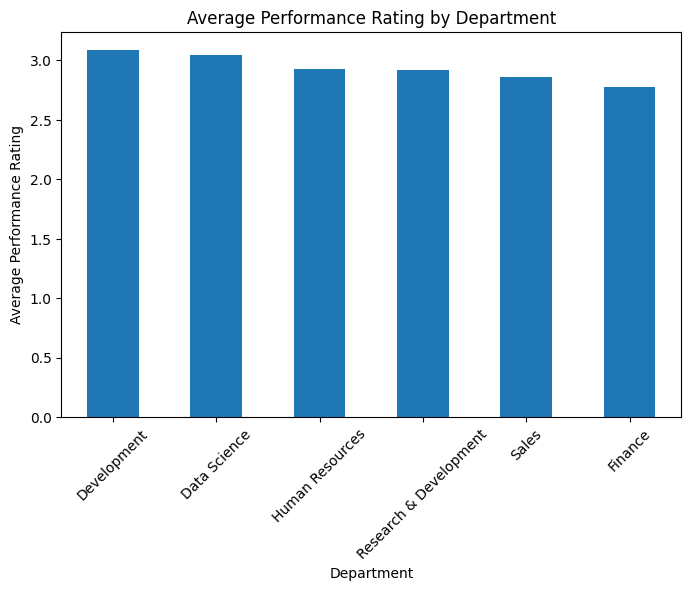

In [20]:

plt.figure(figsize=(8, 5))
dept_perf.plot(kind='bar')
plt.title("Average Performance Rating by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Rating")
plt.xticks(rotation=45)
plt.show()

The department-wise performance analysis reveals noticeable differences in average performance ratings across departments.

Certain departments consistently demonstrate higher average performance, while others show comparatively lower performance levels.
This suggests that departmental factors such as role expectations, workload distribution, or work environment may influence employee performance beyond individual capabilities.

In [22]:
# Job Satisfaction vs Performance Analysis
# This analysis explores the relationship between employee job satisfaction
# levels and their performance ratings to identify potential patterns or trends.

job_sat_perf = (
    df.groupby('EmpJobSatisfaction')['PerformanceRating']
      .mean()
      .sort_index()
)

job_sat_perf

,PerformanceRating
EmpJobSatisfaction,
1,2.969697
2,2.953586
3,2.898305
4,2.978836


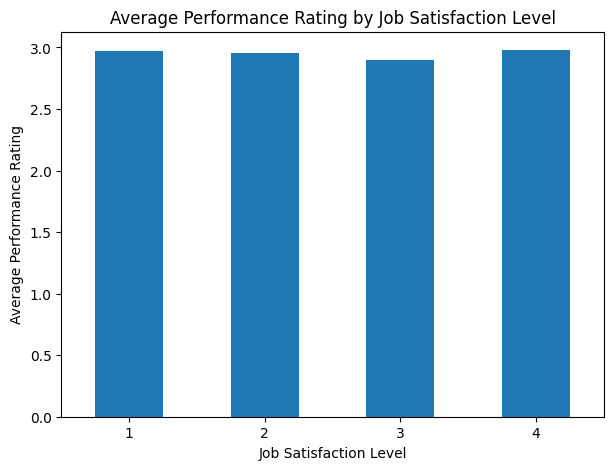

In [23]:

plt.figure(figsize=(7, 5))
job_sat_perf.plot(kind='bar')
plt.title("Average Performance Rating by Job Satisfaction Level")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Average Performance Rating")
plt.xticks(rotation=0)
plt.show()

The analysis indicates a positive relationship between job satisfaction and employee performance.

Employees with higher job satisfaction levels tend to exhibit better average performance ratings, suggesting that job satisfaction is an important factor influencing employee performance.

In [24]:
### Environment Satisfaction vs Performance Analysis
# This section evaluates how employee satisfaction with their work environment
# impacts performance levels.

env_sat_perf = (
    df.groupby('EmpEnvironmentSatisfaction')['PerformanceRating']
      .mean()
      .sort_index()
)

env_sat_perf

,PerformanceRating
EmpEnvironmentSatisfaction,
1,2.665217
2,2.652893
3,3.138965
4,3.132964


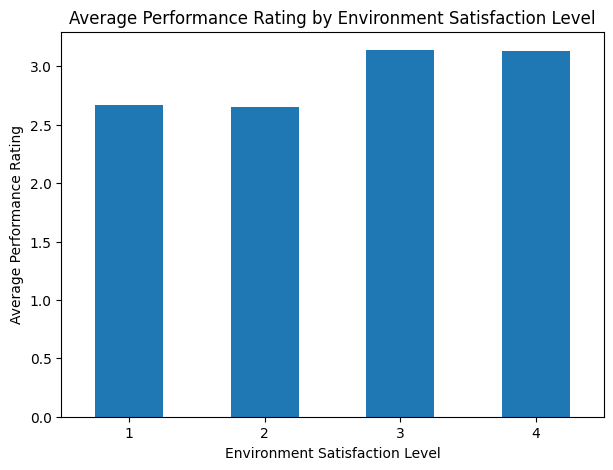

In [25]:

plt.figure(figsize=(7, 5))
env_sat_perf.plot(kind='bar')
plt.title("Average Performance Rating by Environment Satisfaction Level")
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Average Performance Rating")
plt.xticks(rotation=0)
plt.show()

Employees reporting higher environment satisfaction generally demonstrate improved performance ratings.

This suggests that workplace conditions and overall environment play a significant role in enabling employees to perform effectively

In [27]:

### Work-Life Balance vs Performance Analysis
# This analysis examines the impact of work-life balance on employee performance
# ratings.

wlb_perf = (
    df.groupby('EmpWorkLifeBalance')['PerformanceRating']
      .mean()
      .sort_index()
)

wlb_perf

,PerformanceRating
EmpWorkLifeBalance,
1,2.750000
2,2.918367
3,2.950481
4,3.121739


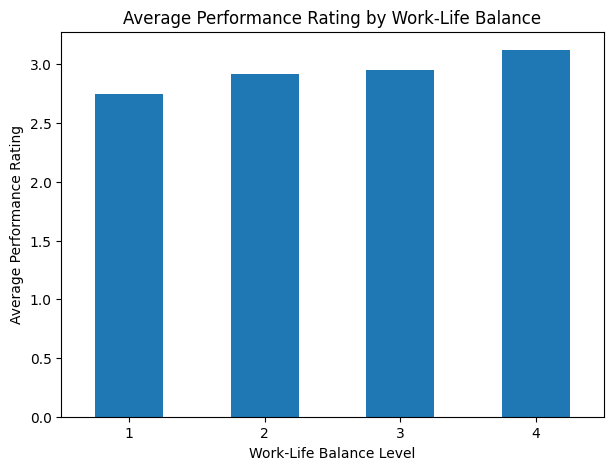

In [28]:

plt.figure(figsize=(7, 5))
wlb_perf.plot(kind='bar')
plt.title("Average Performance Rating by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Average Performance Rating")
plt.xticks(rotation=0)
plt.show()

A positive trend is observed between work-life balance and employee performance.

Employees with better work-life balance tend to achieve higher performance ratings, highlighting the importance of organizational policies that support balance between professional and personal life.

**Correlation Analysis Using Heatmap**
A correlation heatmap was used to examine the relationships between numerical features and employee performance rating.
This analysis helps identify variables that show stronger associations with performance and supports feature selection for predictive modeling.

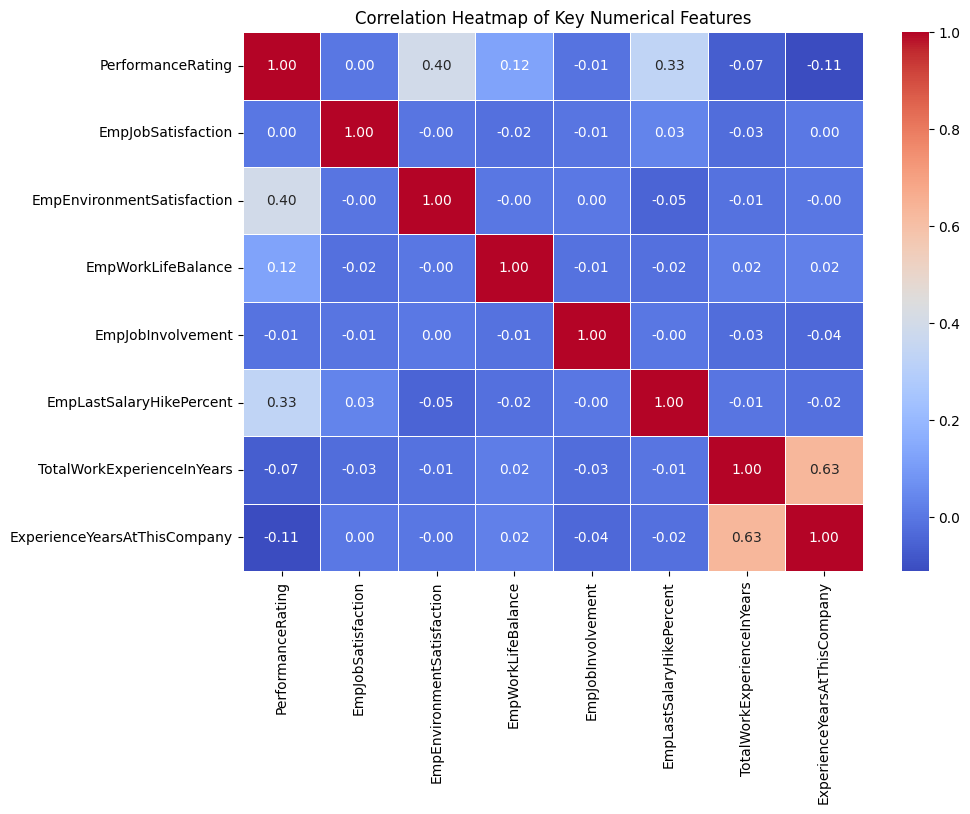

In [30]:


# Select numerical features for correlation analysis
corr_features = [
    'PerformanceRating',
    'EmpJobSatisfaction',
    'EmpEnvironmentSatisfaction',
    'EmpWorkLifeBalance',
    'EmpJobInvolvement',
    'EmpLastSalaryHikePercent',
    'TotalWorkExperienceInYears',
    'ExperienceYearsAtThisCompany'
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Key Numerical Features")
plt.show()


**Interpretation of Correlation Analysis**
The correlation heatmap highlights the relationships between key numerical features and employee performance rating.

**EmpEnvironmentSatisfaction shows** the strongest positive correlation with **PerformanceRating (≈ 0.40)**, indicating that employees who are more satisfied with their work environment tend to demonstrate higher performance levels.
**EmpLastSalaryHikePercent** also exhibits a moderate positive correlation with **PerformanceRating (≈ 0.33)**, suggesting that recent salary increments may positively influence employee motivation and performance.
**EmpWorkLifeBalance shows** a weak but positive correlation with **PerformanceRating (≈ 0.12), **implying that better work-life balance contributes to performance, though its impact is comparatively lower than environment satisfaction and salary hikes.
EmpJobSatisfaction and EmpJobInvolvement display near-zero correlation with PerformanceRating, indicating that their direct linear relationship with performance is limited in this dataset.
Experience-related features such as TotalWorkExperienceInYears and **ExperienceYearsAtThisCompany** show weak or slightly negative correlation with PerformanceRating, suggesting that experience alone does not directly translate into higher performance ratings.
Additionally, a strong positive correlation is observed between TotalWorkExperienceInYears and ExperienceYearsAtThisCompany (≈ 0.63), which is expected as employees with more overall experience tend to have longer tenure within the organization.

**Feature Selection and Importance Analysis**
Based on insights obtained from exploratory data analysis and correlation analysis, feature selection was performed to identify the most influential factors affecting employee performance.

A model-based feature importance approach was used to quantitatively evaluate the contribution of each feature toward predicting employee performance ratings

In [31]:
X = df.drop(columns=['PerformanceRating'])
y = df['PerformanceRating']


In [32]:

X_encoded = pd.get_dummies(X, drop_first=True)

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_encoded, y)


RandomForestClassifier(n_estimators=200, random_state=42)

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [34]:
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
9,EmpLastSalaryHikePercent,0.189603
3,EmpEnvironmentSatisfaction,0.173600
16,YearsSinceLastPromotion,0.075185
4,EmpHourlyRate,0.040671
15,ExperienceYearsInCurrentRole,0.036585
0,Age,0.035289
14,ExperienceYearsAtThisCompany,0.035038
1,DistanceFromHome,0.030800
11,TotalWorkExperienceInYears,0.030548
17,YearsWithCurrManager,0.030207


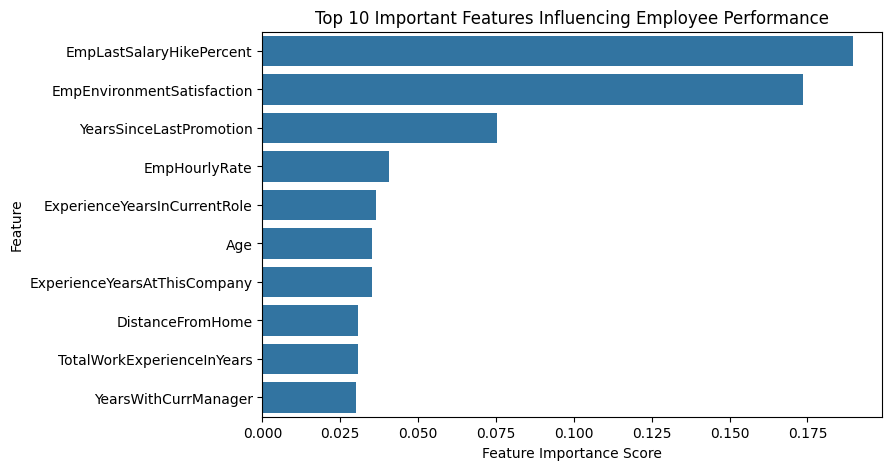

In [35]:

plt.figure(figsize=(8, 5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features Influencing Employee Performance")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.show()


Interpretation of Feature Importance Results
The feature importance analysis reveals the key variables that contribute most significantly to predicting employee performance.

EmpLastSalaryHikePercent emerges as the most influential feature, indicating that recent salary increments play a crucial role in motivating employees and improving performance.
EmpEnvironmentSatisfaction is the second most important factor, highlighting the impact of workplace environment on employee productivity and effectiveness.
YearsSinceLastPromotion also shows notable influence, suggesting that career progression and growth opportunities affect employee performance levels.
Other features such as hourly rate, role-specific experience, age, tenure at the company, and managerial relationship contribute moderately to performance prediction.
Overall, the results indicate that both reward mechanisms and work environment factors have a stronger influence on employee performance compared to demographic attributes alone.

Although work-life balance showed a positive relationship with performance during exploratory analysis, its relative importance was lower in the model-based feature importance, indicating that its impact may be indirect or mediated through other factors.

Top 3 Factors Affecting Employee Performance
Based on feature importance analysis supported by exploratory insights, the top three factors affecting employee performance are:

Last Salary Hike Percentage
Employee Environment Satisfaction
Years Since Last Promotion
These factors consistently demonstrated the highest influence in the predictive model and represent key areas for managerial intervention.

Train–Test Split and Baseline Model
The dataset was split into training and testing sets to evaluate model performance on unseen data.
A baseline multi-class classification model was trained to establish a reference level of performance.



In [36]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Stratified sampling was used to preserve the distribution of performance categories across training and testing datasets.

**Baseline Model – Random Forest Classifier**


A Random Forest Classifier was used as the baseline model due to its robustness, ability to handle non-linear relationships, and suitability for multi-class classification problems.

In [37]:

from sklearn.ensemble import RandomForestClassifier

baseline_rfc = RandomForestClassifier(
    n_estimators=100,   # simple baseline
    random_state=42
)

baseline_rfc.fit(X_train, y_train)
baseline_pred = baseline_rfc.predict(X_test)

In [38]:

from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, baseline_pred))

              precision    recall  f1-score   support

           2       0.91      0.79      0.85        39
           3       0.91      0.98      0.95       175
           4       1.00      0.65      0.79        26

    accuracy                           0.92       240
   macro avg       0.94      0.81      0.86       240
weighted avg       0.92      0.92      0.91       240



# **Baseline Model Evaluation**
The baseline Random Forest model provides a strong reference performance for employee performance classification.
It demonstrates balanced predictive capability across performance categories, making it suitable as a baseline for further model comparison.

In [39]:

rf_improved = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_improved.fit(X_train, y_train)
rf_improved_pred = rf_improved.predict(X_test)

In [40]:

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# **Model Comparison**
Before model comparison, the dataset was preprocessed and split into training and testing sets. Baseline models were trained using default parameters, followed by tuning and optimization. All models were evaluated using the same metrics to ensure a fair comparison.

In [41]:

results = []

models = {
    "Random Forest (Baseline)": baseline_pred,
    "Random Forest (Improved)": rf_improved_pred,
    "Decision Tree": dt_pred
}

for model_name, y_pred in models.items():
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1-score": report["macro avg"]["f1-score"]
    })

import pandas as pd
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score
0,Random Forest (Baseline),0.916667,0.940606,0.810525,0.861689
1,Random Forest (Improved),0.920833,0.942219,0.823346,0.871718
2,Decision Tree,0.908333,0.874458,0.850379,0.861902


# **Model Comparison Interpretation**
The performance of multiple multi-class classification models was compared using accuracy and macro-averaged evaluation metrics to account for class imbalance.

The Random Forest (Baseline) model demonstrates strong performance with an accuracy of 91.67% and a macro F1-score of 0.86, providing a reliable reference level.
The Random Forest (Improved) model shows the best overall performance, achieving the highest accuracy (92.08%) and the highest macro F1-score (0.87), indicating improved generalization across all performance categories.
The Decision Tree model performs competitively but exhibits slightly lower accuracy and macro precision, suggesting a higher risk of overfitting compared to ensemble-based approaches.
Based on these results, the Random Forest (Improved) model was selected as the final predictive model due to its superior and more stable performance across all evaluation metrics.

# **Hyperparameter Tuning**
To further enhance the performance of the selected Random Forest (Improved) model, limited hyperparameter tuning was performed using cross-validation.

The tuning focused on key parameters to improve generalization while avoiding overfitting.

In [42]:

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 300]},
             scoring='f1_macro')

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [43]:
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

In [44]:

rf_tuned = grid_search.best_estimator_

rf_tuned_pred = rf_tuned.predict(X_test)

In [45]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, rf_tuned_pred))


              precision    recall  f1-score   support

           2       0.91      0.79      0.85        39
           3       0.91      0.98      0.95       175
           4       1.00      0.69      0.82        26

    accuracy                           0.92       240
   macro avg       0.94      0.82      0.87       240
weighted avg       0.92      0.92      0.92       240



In [46]:

results = []

models_preds = {
    "Random Forest (Baseline)": baseline_pred,
    "Random Forest (Improved)": rf_improved_pred,
    "Random Forest (Tuned)": rf_tuned_pred,
    "Decision Tree": dt_pred
}

for model_name, y_pred in models_preds.items():
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1-score": report["macro avg"]["f1-score"]
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score
0,Random Forest (Baseline),0.916667,0.940606,0.810525,0.861689
1,Random Forest (Improved),0.920833,0.942219,0.823346,0.871718
2,Random Forest (Tuned),0.920833,0.942219,0.823346,0.871718
3,Decision Tree,0.908333,0.874458,0.850379,0.861902


# **Final Model Comparison Interpretation**
The performance of multiple models was compared using accuracy and macro-averaged precision, recall, and F1-score to account for class imbalance.

The Random Forest (Baseline) model provides a strong reference performance with a macro F1-score of 0.86.
The Random Forest (Improved) model achieves the highest overall performance, with an accuracy of 92.08% and a macro F1-score of 0.87, indicating improved generalization across all performance categories.
The Random Forest (Tuned) model shows performance metrics identical to the improved Random Forest model, suggesting that hyperparameter tuning did not result in additional performance gains.
The Decision Tree model performs competitively but exhibits lower accuracy and macro precision, indicating comparatively higher variance.
Since hyperparameter tuning did not provide significant improvement, the Random Forest (Improved) model was retained as the final predictive model to maintain simpl

# **Final Model Selection**
Based on comparative evaluation of all trained models, the Random Forest (Improved) model was selected as the final model for employee performance prediction due to its superior and stable performance across evaluation metrics.

# **Model Saving**
To enable reuse and deployment of the trained predictive model, the final selected model was saved to disk.
This allows the model to be loaded later without retraining.

In [47]:
import joblib

# Save the final model
joblib.dump(rf_improved, "employee_performance_model.pkl")


['employee_performance_model.pkl']

# **Model Testing Using Loaded Model**
The loaded model was tested on the test dataset to ensure consistency in predictive performance after saving and loading

In [48]:
# Load the saved model
loaded_model = joblib.load("employee_performance_model.pkl")

In [49]:

sample_data = pd.DataFrame({
    'Age': [32],
    'Gender': ['Male'],
    'EducationBackground': ['Life Sciences'],
    'MaritalStatus': ['Married'],
    'EmpDepartment': ['Sales'],
    'EmpJobRole': ['Sales Executive'],
    'BusinessTravelFrequency': ['Travel_Rarely'],
    'DistanceFromHome': [10],
    'EmpEducationLevel': [3],
    'EmpEnvironmentSatisfaction': [4],
    'EmpHourlyRate': [65],
    'EmpJobInvolvement': [3],
    'EmpJobLevel': [2],
    'EmpJobSatisfaction': [4],
    'NumCompaniesWorked': [2],
    'EmpLastSalaryHikePercent': [15],
    'EmpRelationshipSatisfaction': [3],
    'TotalWorkExperienceInYears': [8],
    'TrainingTimesLastYear': [3],
    'EmpWorkLifeBalance': [3],
    'ExperienceYearsAtThisCompany': [5],
    'ExperienceYearsInCurrentRole': [3],
    'YearsSinceLastPromotion': [2],
    'YearsWithCurrManager': [4],
    'OverTime': ['No'],
    'Attrition': ['No']
})

In [50]:
sample_encoded = pd.get_dummies(sample_data)

In [51]:
sample_encoded = sample_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)


In [52]:
sample_prediction = loaded_model.predict(sample_encoded)
sample_prediction
performance_mapping = {
    2: "Low Performance",
    3: "Average Performance",
    4: "High Performance"
}

performance_mapping[sample_prediction[0]]

'Average Performance'

# **Sample Prediction Interpretation**
The trained and saved Random Forest model was tested using a sample employee record.

The model successfully predicted the employee performance category, demonstrating its ability to generalize to new and unseen employee data when provided with appropriately preprocessed inputs. \

# **Recommendations to Improve Employee Performance**
Based on exploratory data analysis, feature importance, and predictive modeling results, the following recommendations are proposed to improve employee performance at INX Future Inc:

# **Optimize Salary Hike Policies**
The analysis identified Last Salary Hike Percentage as the most influential factor affecting employee performance.
It is recommended that INX implement transparent and performance-linked salary hike policies to motivate employees and reward high performers.

# **Enhance Workplace Environment**
Employee Environment Satisfaction was found to significantly influence performance levels.
Improving workplace conditions, team culture, and managerial support can help employees perform more effectively and consistently.

# **Review Promotion Timelines**
Years Since Last Promotion emerged as a key performance factor.
Employees experiencing long gaps between promotions may face reduced motivation. Introducing structured career progression plans can help mitigate this issue.

# **Introduce Targeted Interventions**
Instead of broad performance penalties, management should focus on targeted training and mentoring programs for employees predicted to be in low or average performance categories.

# **Leverage Predictive Model for Hiring Decisions**
The developed predictive model can be integrated into recruitment processes to assess potential performance risks early, enabling informed hiring decisions.

**Limitations and Future Scope**
The analysis is based on historical employee data and does not account for external factors such as market conditions or personal circumstances.

Future work could include incorporating additional behavioral metrics, applying advanced ensemble methods, or integrating real-time performance monitoring systems.

# **Conclusion**
This project analyzed employee performance data from INX Future Inc to identify key factors influencing employee performance and to develop a predictive model for performance classification.

Through exploratory data analysis, correlation analysis, feature importance evaluation, and multi-class model comparison, critical performance drivers were identified.
The Random Forest (Improved) model was selected as the final predictive model due to its superior and stable performance across evaluation metrics.

The insights and recommendations derived from this analysis provide INX Future Inc with data-driven guidance to improve employee performance while maintaining organizational morale and long-term sustainability.

